# CNNs for Cancer Image Patch Classification

A study of convolutional neural network architectures for **binary classification
of histopathology image patches** — distinguishing patches that contain
metastatic tumor tissue from those that do not.

This work is based on the
[Histopathologic Cancer Detection](https://www.kaggle.com/competitions/histopathologic-cancer-detection)
competition on Kaggle.

| | |
|---|---|
| **Author** | Abraham Pérez |
| **Task** | Binary image classification — *tumor* vs. *normal* tissue |
| **Data** | 220,025 labeled 96×96 px RGB patches |
| **Framework** | TensorFlow / Keras |
| **Best model** | Transfer learning (MobileNetV2, fine-tuned) — **0.947 validation AUC** |

---

## Contents
1. [Problem Description](#problem-description)
2. [Exploratory Data Analysis](#eda)
3. [Modeling &amp; Analysis](#modeling)
4. [Results](#results)
5. [Conclusion](#conclusion)
6. [References](#references)

<a id="problem-description"></a>
# 1. Problem Description

This project builds and compares convolutional neural networks for a **binary
image-classification** task: given a 96×96 px RGB patch cropped from a digital
pathology scan, predict whether the patch contains **metastatic tumor tissue**.
Automating this kind of screening can help pathologists triage slides faster and
more consistently.

The data comes from the **PatchCamelyon (PCam)** benchmark — 96×96 px patches
extracted from the **Camelyon16** collection of whole-slide lymph-node
histopathology scans. It is distributed on Kaggle as the
[Histopathologic Cancer Detection dataset](https://www.kaggle.com/competitions/histopathologic-cancer-detection).
The label is determined by the **center 32×32 px** region of each patch; the
surrounding pixels supply context and keep the convolutions from being dominated
by edge padding. Every image carries a ground-truth label (`1` = tumor,
`0` = normal), and the workflow below proceeds through the standard stages:
**EDA → preprocessing → modeling → evaluation**.

<a id="eda"></a>
# 2. Exploratory Data Analysis

Before modeling, we load the data and build a high-level picture of its shape,
class balance, and pixel statistics. As the sample patches below show, the two
classes are not obviously distinguishable to the untrained eye — which is exactly
what motivates a learned approach.

In [8]:
# Core scientific stack plus TensorFlow / Keras.
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tifffile import imread
import cv2

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import keras
from keras import layers
from keras import initializers

# Fix all RNG seeds for reproducible runs.
keras.utils.set_random_seed(42)

In [9]:
# ---- Plot styling -----------------------------------------------------------
# A small, consistent theme applied to every figure below: soft colors, a light
# grid, and no top/right spines for a cleaner, more professional look.
import matplotlib as mpl

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 1.0,
    'axes.grid': True,
    'grid.color': '#e9e9e9',
    'grid.linewidth': 0.8,
    'axes.axisbelow': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlepad': 12,
    'axes.labelsize': 11,
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'text.color': '#222222',
    'font.size': 11,
    'legend.frameon': False,
})

# Semantic color palette reused across the notebook.
PALETTE = {
    'no_cancer': '#4C9F70',   # soft green
    'cancer':    '#E15554',   # soft red
    'train':     '#2C6E9B',   # blue  (training curves)
    'val':       '#E1A730',   # amber (validation curves)
}

In [10]:
import glob
# Auto-locate the dataset folder that contains train_labels.csv.
DATA_DIR = os.path.dirname((glob.glob('/kaggle/input/*/train_labels.csv') + glob.glob('/kaggle/input/*/*/train_labels.csv'))[0])
print('DATA_DIR =', DATA_DIR)
train_dir = os.path.join(DATA_DIR, 'train') + '/'
test_dir = os.path.join(DATA_DIR, 'test') + '/'

DATA_DIR = /kaggle/input/competitions/histopathologic-cancer-detection


In [11]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_labels.csv'))
print(train_df.shape)

(220025, 2)


In [12]:
print(train_df.head())

                                         id  label
0  f38a6374c348f90b587e046aac6079959adf3835      0
1  c18f2d887b7ae4f6742ee445113fa1aef383ed77      1
2  755db6279dae599ebb4d39a9123cce439965282d      0
3  bc3f0c64fb968ff4a8bd33af6971ecae77c75e08      0
4  068aba587a4950175d04c680d38943fd488d6a9d      0


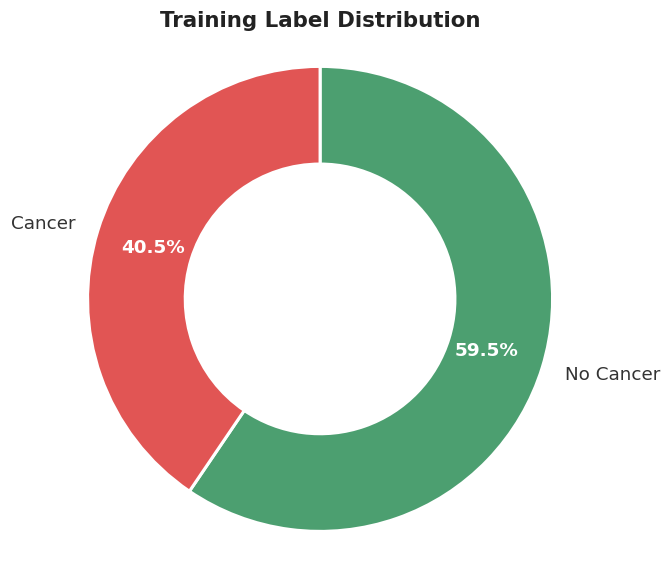

In [13]:
# Class balance as a donut chart. Sorting the index keeps 0 -> No Cancer and
# 1 -> Cancer aligned with the labels regardless of value_counts ordering.
label_counts = train_df['label'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    label_counts,
    labels=['No Cancer', 'Cancer'],
    colors=[PALETTE['no_cancer'], PALETTE['cancer']],
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    pctdistance=0.75,
    wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=12, color='#333333'),
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
ax.set_title('Training Label Distribution', fontsize=14, fontweight='bold')
ax.axis('equal')
plt.show()

In [14]:
train_files = os.listdir(train_dir)
train_files[:5]

['d43c081bafa286f9c1f7e921883f26ceafebc912.tif',
 '092d0eedebce504847715ee046b6ad74b57599b4.tif',
 'b0d2582c6218a8764323fc940b41312282b99bf4.tif',
 '187c99df762f13f99818e5593d4bab4c6577e7e3.tif',
 '7c5270c83837de5a5cbb2dca511559dc39d19d53.tif']

In [15]:
img_0 = imread(os.path.join(train_dir, train_files[0]))
img_0.shape

(96, 96, 3)

The training set contains **220,025** examples, and the number of labels matches the number of files under `train/`. Each image is a **96×96 px, 3-channel (RGB)** TIFF (`.tif`). Roughly **40%** of the images are labeled positive for cancer, so the classes are only moderately imbalanced.

Below is a random sample of patches with their labels. To the untrained eye, it is hard to tell which ones contain cancerous tissue.

In [16]:
def load_image(iid, image_dir=train_dir):
    path = image_dir + iid + '.tif'
    # print(f'Loading {iid} from {path}')
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

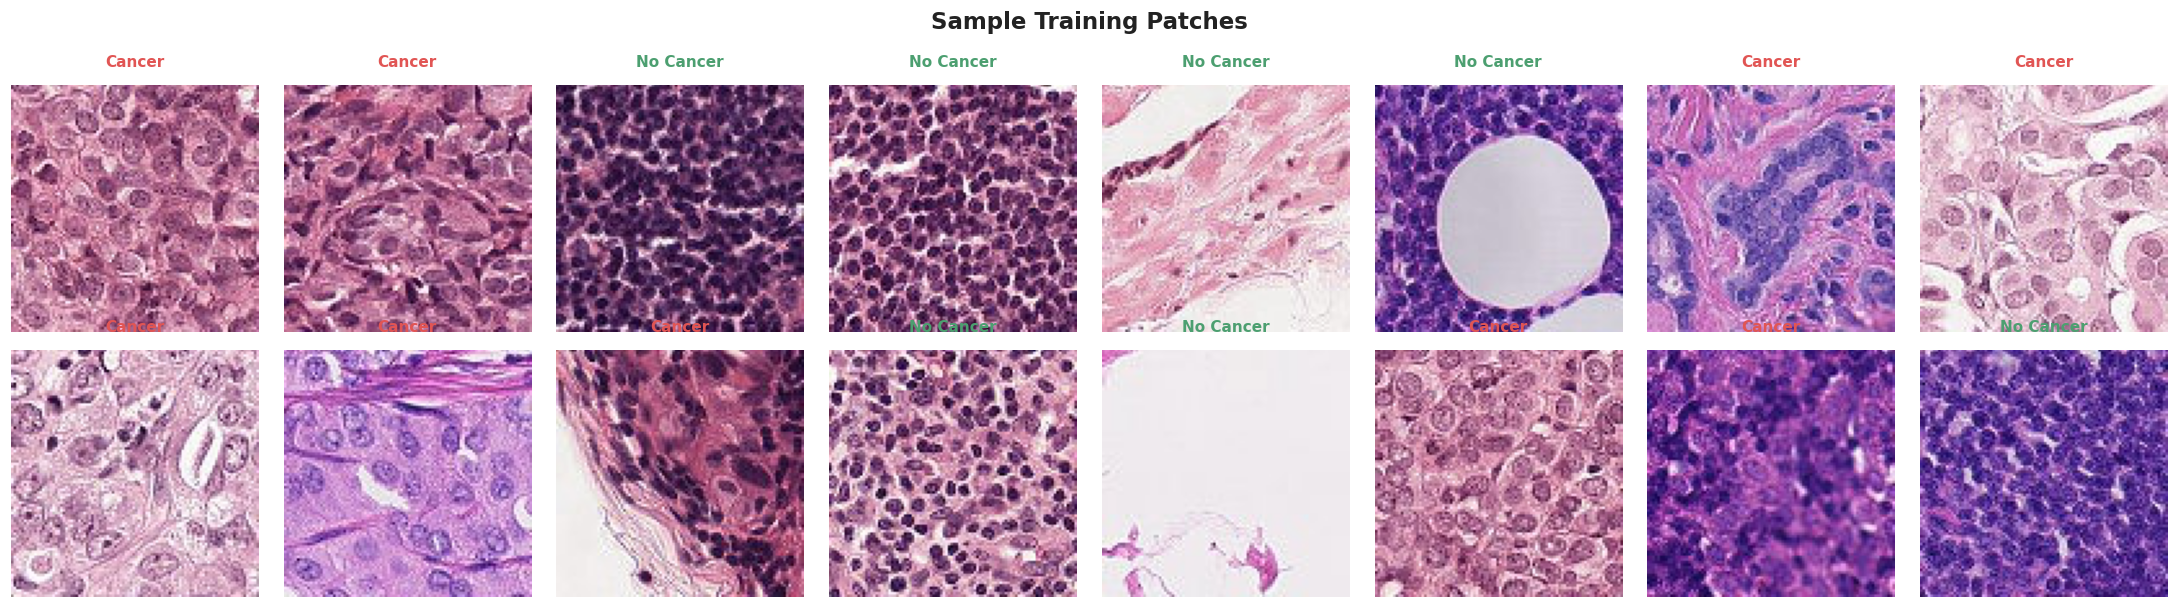

In [17]:
fig, axes = plt.subplots(nrows=2, ncols=8, figsize=(20, 5.5))
fig.suptitle('Sample Training Patches', fontsize=15, fontweight='bold', y=1.00)
for idx, i in enumerate(np.random.choice(train_df['id'], 16)):
    img = load_image(i)
    ax = axes.flat[idx]
    ax.imshow(img)
    ax.axis('off')
    id = i.split('.')[0]
    l = train_df[train_df.id == id].values[0][1]
    label_txt = 'Cancer' if l == 1 else 'No Cancer'
    ax.set_title(label_txt, fontsize=10, fontweight='bold',
                 color=PALETTE['cancer'] if l == 1 else PALETTE['no_cancer'])
plt.tight_layout()
plt.show()

Finally, we inspect the per-channel RGB statistics and the overall pixel-intensity distribution. Because the dataset is large, we take a random subsample, compute the mean/std of each channel, and plot a histogram of pixel intensities.

The mean/std values look reasonable and reveal no unusual patterns worth investigating, and the intensity distribution shows that most of the pixel space carries non-zero values — the patches are largely filled with tissue rather than blank space.

In [18]:
image_samples = np.array([load_image(id) for id in np.random.choice(train_df['id'], 5000)])

Mean pixel values (R,G,B): [179.54671233 140.13740747 178.04624421]
Std pixel values (R,G,B): [60.99976511 72.28502794 55.27051975]


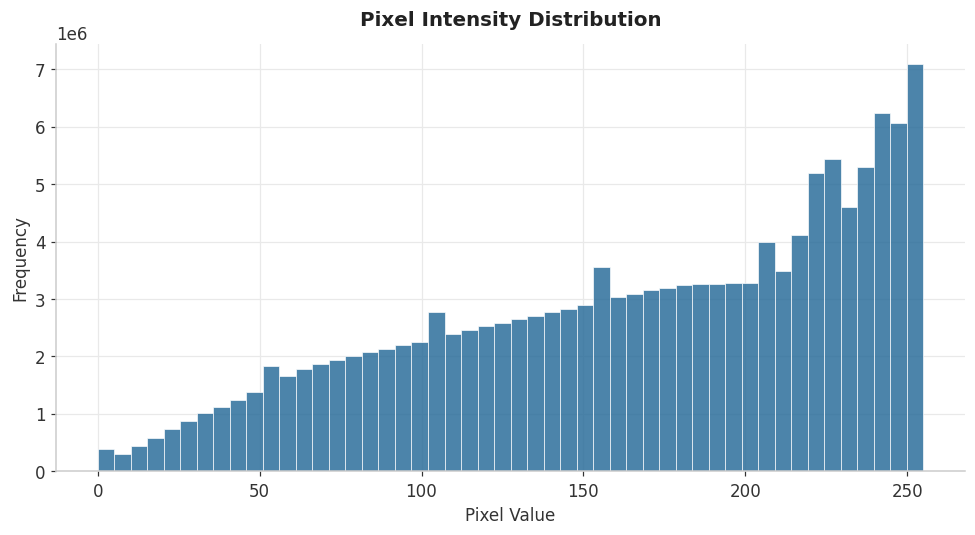

In [19]:
# Get the mean and stddev of pixels per channel (RGB color)
mean_pixel = np.mean(image_samples, axis=(0, 1, 2))  # Mean per channel
std_pixel = np.std(image_samples, axis=(0, 1, 2))    # Std deviation per channel

print(f"Mean pixel values (R,G,B): {mean_pixel}")
print(f"Std pixel values (R,G,B): {std_pixel}")

# Histogram of pixel values
plt.figure(figsize=(9, 5))
plt.hist(image_samples.ravel(), bins=50, color=PALETTE['train'],
         alpha=0.85, edgecolor='white', linewidth=0.5)
plt.title('Pixel Intensity Distribution')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

<a id="modeling"></a>
# 3. Modeling & Analysis

With the data understood, we move on to building and training the models.

## Preprocessing

The full dataset is large, and preloading every image into memory would risk very
long runtimes or out-of-memory errors. To stay within a modest memory budget, we
train on a **balanced subset**, drawing an equal number of positive and negative
examples (20,000 each). Balancing removes class prior as a confound, so that the
differences we see between models reflect architecture rather than label
frequencies.

In [20]:
# Create a smaller dataset with equal number of positive and negative examples.
TRAIN_SIZE_PER_LABEL=20000
negative = train_df[train_df['label'] == 0].sample(TRAIN_SIZE_PER_LABEL)
positive = train_df[train_df['label'] == 1].sample(TRAIN_SIZE_PER_LABEL)
neg_and_pos = pd.concat([negative, positive], axis=0).reset_index(drop=True)
train_df_small = neg_and_pos.sample(frac=1).reset_index(drop=True)

In [21]:
# Create X and y for training based on the smaller dataset.
X = np.array([load_image(i) for i in train_df_small['id']])
y = train_df_small['label'].values

Additional preprocessing is handled *inside* the model as its first layers (see below), which keeps the input pipeline simple and consistent between training and inference.

## Model Build and Training

The dataset is ready, so we build and train the models. In every architecture the
first layers handle preprocessing:

- **`Rescaling(1./255)`** — normalizes the RGB values from `[0, 255]` into `[0, 1]`.
- **`Cropping2D(32)`** — keeps only the center **32×32 px** region that defines the
  label (used in Model #1 only).

### Model #1 — Simple Baseline

The baseline is deliberately simple. After the preprocessing layers it stacks
three `Conv2D` + `MaxPooling2D` blocks for feature extraction, then a single fully
connected layer that funnels (through dropout) to the final sigmoid. The
convolution layers progressively grow the number of filters **32 → 64 → 128**.

In [22]:
# Simple Baseline Model
m1 = keras.Sequential([
    layers.Input(shape=(96, 96, 3)),
    layers.Rescaling(1./255),
    layers.Cropping2D(cropping=32),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])
m1.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy', 'auc'])
m1.summary()

I0000 00:00:1790781507.660446      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790781507.663277      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,041 (621.25 KB)

 Trainable params: 159,041 (621.25 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
es1 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
h1 = m1.fit(X, y, validation_split=0.2, epochs=50, callbacks=[es1])

Epoch 1/50
  47/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5138 - auc: 0.5163 - loss: 0.6933

I0000 00:00:1790781517.094148     179 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7192 - auc: 0.7812 - loss: 0.5672 - val_accuracy: 0.7423 - val_auc: 0.8078 - val_loss: 0.5413
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7488 - auc: 0.8121 - loss: 0.5309 - val_accuracy: 0.7458 - val_auc: 0.8160 - val_loss: 0.5321
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7541 - auc: 0.8209 - loss: 0.5206 - val_accuracy: 0.7511 - val_auc: 0.8227 - val_loss: 0.5239
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7599 - auc: 0.8269 - loss: 0.5128 - val_accuracy: 0.7573 - val_auc: 0.8285 - val_loss: 0.5156
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7637 - auc: 0.8333 - loss: 0.5046 - val_accuracy: 0.7620 - val_auc: 0.8330 - val_loss: 0.5112
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7667 - auc: 0.8372 - loss: 0.4989 - val_accuracy: 0.7623 - val_auc: 0.8344 - val_loss: 0.5088
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━

In [24]:
# Prepare test data for evaluation.
test_files = os.listdir(test_dir)
test_ids = [f.split('.')[0] for f in test_files]
test_X = np.array([load_image(i, image_dir=test_dir) for i in test_ids])

In [25]:
results = m1.predict(test_X)
results = results.reshape(-1)
results.shape

1796/1796 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


(57458,)

In [26]:
results_df = pd.DataFrame({
    'id': test_ids,
    'label': results.tolist(),
})

> **Model #1 — validation AUC: `0.856`** (baseline).

### Model #2 — Deeper + Batch Normalization

Model #2 uses a deeper architecture: **five** `Conv2D` blocks, each followed by a
`BatchNormalization` layer to improve training stability given the larger
parameter count. As before, it funnels through a fully connected layer (with
dropout) to the final sigmoid. The center-crop is dropped here, so the model sees
the full 96×96 patch.

In [28]:
# More Complex Model
m2 = keras.Sequential([
    layers.Input(shape=(96, 96, 3)),
    layers.Rescaling(1./255),
    # layers.Cropping2D(cropping=32),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(512, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])
m2.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy', 'auc'])
m2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 94, 94, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 45, 45, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 2, 2, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2, 2, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,704,129 (6.50 MB)

 Trainable params: 1,702,145 (6.49 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [29]:
es2 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
h2 = m2.fit(X, y,
            validation_split=0.2,
            epochs=50,
            callbacks=[es2],
           )

Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.7731 - auc: 0.8516 - loss: 0.5093 - val_accuracy: 0.8037 - val_auc: 0.8969 - val_loss: 0.4369
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.8218 - auc: 0.9004 - loss: 0.4017 - val_accuracy: 0.8257 - val_auc: 0.9114 - val_loss: 0.4004
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.8471 - auc: 0.9238 - loss: 0.3524 - val_accuracy: 0.8231 - val_auc: 0.9230 - val_loss: 0.4142
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.8719 - auc: 0.9442 - loss: 0.3025 - val_accuracy: 0.8326 - val_auc: 0.9248 - val_loss: 0.4378
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.9044 - auc: 0.9656 - loss: 0.2379 - val_accuracy: 0.8170 - val_auc: 0.9057 - val_loss: 0.5195
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.9356 - auc: 0.9830 - loss: 0.1659 - val_accuracy: 0.8397 - val_auc: 0.9114 - val_loss: 0.4550
Epoch 7/50
1000/

In [30]:
results = m2.predict(test_X)
results = results.reshape(-1)
results.shape

1796/1796 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step


(57458,)

In [31]:
results_df = pd.DataFrame({
    'id': test_ids,
    'label': results.tolist(),
})

> **Model #2 — validation AUC: `0.925`** — best of the from-scratch CNNs.

### Model #3 — Deeper Classification Head

Model #3 keeps the five-block convolutional base but adds a **deeper fully
connected head** (1024 → 512 → 1) with extra dropout, raising the parameter count
by roughly 1M to test whether a heavier classifier helps.

In [33]:
# More Complex Model (Deeper Classification Layers)
m3 = keras.Sequential([
    layers.Input(shape=(96, 96, 3)),
    layers.Rescaling(1./255),
    # layers.Cropping2D(cropping=32),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (2,2), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(512, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.5),
    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])
m3.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy', 'auc'])
m3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 94, 94, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 46, 46, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 46, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 2, 2, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 2, 2, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,612,929 (9.97 MB)

 Trainable params: 2,610,945 (9.96 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [34]:
es3 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
h3 = m3.fit(X, y,
            validation_split=0.2,
            epochs=50,
            callbacks=[es3],
           )

Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.7560 - auc: 0.8299 - loss: 0.5378 - val_accuracy: 0.7981 - val_auc: 0.8861 - val_loss: 0.4335
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.8037 - auc: 0.8828 - loss: 0.4331 - val_accuracy: 0.8202 - val_auc: 0.9103 - val_loss: 0.3954
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.8243 - auc: 0.9013 - loss: 0.3989 - val_accuracy: 0.7965 - val_auc: 0.9078 - val_loss: 0.4370
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.8409 - auc: 0.9179 - loss: 0.3656 - val_accuracy: 0.8070 - val_auc: 0.9085 - val_loss: 0.4341
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.8574 - auc: 0.9310 - loss: 0.3359 - val_accuracy: 0.7816 - val_auc: 0.8770 - val_loss: 0.4566
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.8741 - auc: 0.9447 - loss: 0.3019 - val_accuracy: 0.8244 - val_auc: 0.9128 - val_loss: 0.4298
Epoch 7/50
1000/

In [35]:
results = m3.predict(test_X)
results = results.reshape(-1)
results.shape

1796/1796 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step


(57458,)

In [36]:
results_df = pd.DataFrame({
    'id': test_ids,
    'label': results.tolist(),
})

> **Model #3 — validation AUC: `0.930` peak, but unstable.** Its validation loss
> diverges sharply late in training — a textbook overfitting signature (see the
> curves in [Results](#results)).

## Extending the Models

The sections above explored progressively deeper architectures trained from
scratch. Here we implement two standard techniques for getting more out of a
limited training set: **data augmentation** and **transfer learning** with a
pre-trained backbone.

### Shared Augmentation Layers

Augmentation is applied only during training (the layers pass images through
unchanged at inference). Because histopathology patches have no canonical
orientation, flips and rotations are label-preserving — a natural way to enlarge
the effective training set and discourage the model from memorizing specifics.

In [38]:
# Data augmentation block shared by the models below.
# These layers are only active during training and pass images through unchanged
# at inference time, so no extra handling is needed for prediction/submission.
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name='data_augmentation')

### Model #4 — Best Base + Data Augmentation

Model #4 reuses Model #2's architecture (the best from-scratch model) and inserts
the augmentation block ahead of the preprocessing layers. This isolates the effect
of augmentation: any change in performance is attributable to it rather than to a
different backbone.

In [39]:
# Model #2 architecture with a data-augmentation front-end.
m4 = keras.Sequential([
    layers.Input(shape=(96, 96, 3)),
    data_augmentation,
    layers.Rescaling(1./255),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(512, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])
m4.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy', 'auc'])
m4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 94, 94, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 45, 45, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 2, 2, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 2, 2, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,704,129 (6.50 MB)

 Trainable params: 1,702,145 (6.49 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [40]:
es4 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
h4 = m4.fit(X, y, validation_split=0.2, epochs=50, callbacks=[es4])

Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 37s 29ms/step - accuracy: 0.7707 - auc: 0.8473 - loss: 0.5061 - val_accuracy: 0.6661 - val_auc: 0.8349 - val_loss: 0.7280
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.8087 - auc: 0.8885 - loss: 0.4233 - val_accuracy: 0.7130 - val_auc: 0.8273 - val_loss: 0.6551
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.8216 - auc: 0.9012 - loss: 0.3994 - val_accuracy: 0.7361 - val_auc: 0.8326 - val_loss: 0.5860
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.8333 - auc: 0.9112 - loss: 0.3796 - val_accuracy: 0.6848 - val_auc: 0.7860 - val_loss: 0.6872
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.8423 - auc: 0.9182 - loss: 0.3651 - val_accuracy: 0.7525 - val_auc: 0.8701 - val_loss: 0.5285
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.8495 - auc: 0.9254 - loss: 0.3489 - val_accuracy: 0.7303 - val_auc: 0.8486 - val_loss: 0.5735
Epoch 7/50
1000/

In [41]:
# Generate predictions on the held-out test set (Model #4).
results = m4.predict(test_X).reshape(-1)
results_df = pd.DataFrame({'id': test_ids, 'label': results.tolist()})
results_df.head()

1796/1796 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step


,id,label
0,a7ea26360815d8492433b14cd8318607bcf99d9e,0.335322
1,59d21133c845dff1ebc7a0c7cf40c145ea9e9664,0.033176
2,5fde41ce8c6048a5c2f38eca12d6528fa312cdbb,0.003977
3,bd953a3b1db1f7041ee95ff482594c4f46c73ed0,0.437912
4,523fc2efd7aba53e597ab0f69cc2cbded7a6ce62,0.025268


### Model #5 — Transfer Learning with MobileNetV2

Instead of training from scratch, Model #5 uses **MobileNetV2** — pre-trained on
ImageNet — as a feature extractor, topped with a small classification head. This
is a deeper, more expressive backbone than the custom CNNs, at a fraction of the
training cost. Note the different normalization: MobileNetV2 expects inputs scaled
to `[-1, 1]` rather than `[0, 1]`.

Training proceeds in two stages: (1) train the head with the base **frozen**, then
(2) **fine-tune** the top of the base with a very low learning rate, so the
pre-trained features adapt to histopathology without being washed out.

In [42]:
# Stage 1: frozen pre-trained base + a lightweight classification head.
base_model = keras.applications.MobileNetV2(
    input_shape=(96, 96, 3), include_top=False, weights='imagenet')
base_model.trainable = False

m5 = keras.Sequential([
    layers.Input(shape=(96, 96, 3)),
    data_augmentation,
    layers.Rescaling(1./127.5, offset=-1),   # MobileNetV2 expects inputs in [-1, 1]
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])
m5.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy', 'auc'])
m5.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [43]:
es5 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
h5 = m5.fit(X, y, validation_split=0.2, epochs=50, callbacks=[es5])

Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - accuracy: 0.8026 - auc: 0.8820 - loss: 0.4356 - val_accuracy: 0.8188 - val_auc: 0.9037 - val_loss: 0.4019
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.8201 - auc: 0.9029 - loss: 0.3943 - val_accuracy: 0.8288 - val_auc: 0.9109 - val_loss: 0.3809
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.8271 - auc: 0.9077 - loss: 0.3849 - val_accuracy: 0.8298 - val_auc: 0.9124 - val_loss: 0.3788
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.8262 - auc: 0.9065 - loss: 0.3884 - val_accuracy: 0.8328 - val_auc: 0.9129 - val_loss: 0.3770
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.8295 - auc: 0.9085 - loss: 0.3843 - val_accuracy: 0.8332 - val_auc: 0.9144 - val_loss: 0.3769
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.8283 - auc: 0.9083 - loss: 0.3847 - val_accuracy: 0.8322 - val_auc: 0.9119 - val_loss: 0.3832
Epoch 7/50
1000/

In [44]:
# Stage 2 (optional): unfreeze the top of the base and fine-tune with a low LR.
base_model.trainable = True
for layer in base_model.layers[:-30]:      # keep the earlier layers frozen
    layer.trainable = False
m5.compile(optimizer=Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=['accuracy', 'auc'])
es5_ft = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
h5_ft = m5.fit(X, y, validation_split=0.2, epochs=20, callbacks=[es5_ft])

Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.7768 - auc: 0.8654 - loss: 0.5737 - val_accuracy: 0.8305 - val_auc: 0.9116 - val_loss: 0.3919
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 29s 29ms/step - accuracy: 0.8128 - auc: 0.8954 - loss: 0.4377 - val_accuracy: 0.8307 - val_auc: 0.9147 - val_loss: 0.3839
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.8244 - auc: 0.9068 - loss: 0.4054 - val_accuracy: 0.8361 - val_auc: 0.9193 - val_loss: 0.3731
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.8328 - auc: 0.9156 - loss: 0.3785 - val_accuracy: 0.8388 - val_auc: 0.9228 - val_loss: 0.3612
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.8429 - auc: 0.9227 - loss: 0.3584 - val_accuracy: 0.8400 - val_auc: 0.9234 - val_loss: 0.3574
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.8480 - auc: 0.9263 - loss: 0.3480 - val_accuracy: 0.8479 - val_auc: 0.9291 - val_loss: 0.3443
Epoch 7/20
1000/

In [45]:
# Generate predictions on the held-out test set (Model #5).
results = m5.predict(test_X).reshape(-1)
results_df = pd.DataFrame({'id': test_ids, 'label': results.tolist()})
results_df.head()

1796/1796 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step


,id,label
0,a7ea26360815d8492433b14cd8318607bcf99d9e,0.566015
1,59d21133c845dff1ebc7a0c7cf40c145ea9e9664,0.012460
2,5fde41ce8c6048a5c2f38eca12d6528fa312cdbb,0.074820
3,bd953a3b1db1f7041ee95ff482594c4f46c73ed0,0.708281
4,523fc2efd7aba53e597ab0f69cc2cbded7a6ce62,0.555618


<a id="results"></a>
# 4. Results

All models are compared on the same held-out **20% validation split** using
**AUC** (area under the ROC curve), the natural metric for an imbalance-sensitive
binary screening task. The table reports each model's best validation AUC.

| Model | Approach | Parameters | Val. AUC |
|:------|:---------|-----------:|:--------:|
| Model #1 | 3-block CNN (baseline) | 159,041 | 0.856 |
| Model #2 | 5-block CNN + batch norm | 1,702,145 | 0.925 |
| Model #3 | 5-block CNN + deep head | 2,610,945 | 0.930\* |
| Model #4 | Model #2 + augmentation | 1,702,145 | 0.914 |
| Model #5 | MobileNetV2, frozen | ~2.3M | 0.914 |
| **Model #5** | **MobileNetV2, fine-tuned** | **~2.3M** | **0.947** 🏆 |

\* Model #3 reaches a high peak, but its validation loss diverges, so the score is
not trustworthy — more capacity without more regularization simply overfits.

**What the training curves show**

- **Model #1** begins overfitting after ~6–7 epochs, visible as a growing gap
  between the training and validation metrics.
- **Model #2** converges quickly (~4–5 epochs); afterward its validation metrics
  swing, hinting at a learning rate that is slightly high.
- **Model #3**, despite ~1M extra parameters, does *not* beat Model #2 and
  overfits harder — more capacity is not automatically better.
- **Model #4 (augmentation)** trades a little peak AUC for markedly **better
  generalization**: its validation loss keeps decreasing instead of diverging,
  giving the cleanest curves of the from-scratch models.
- **Model #5 (transfer learning)** starts strong even with a frozen backbone, and
  **fine-tuning lifts it to the best AUC overall (0.947)** at a fraction of the
  training effort.

> In separate experiments, more than doubling the balanced training set
> (40k → 100k patches) did **not** improve results — a reminder that once the
> classes are balanced, architecture and regularization often matter more than
> raw data volume.

In [46]:
def graph_train_hist(h):
    """Plot training/validation AUC, loss, and accuracy side by side."""
    hist = h.history
    epochs = range(1, len(hist['loss']) + 1)
    panels = [
        ('auc', 'val_auc', 'AUC'),
        ('loss', 'val_loss', 'Loss'),
        ('accuracy', 'val_accuracy', 'Accuracy'),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (train_key, val_key, name) in zip(axes, panels):
        ax.plot(epochs, hist[train_key], color=PALETTE['train'],
                marker='o', markersize=4, linewidth=2, label=f'Training {name}')
        ax.plot(epochs, hist[val_key], color=PALETTE['val'],
                marker='s', markersize=4, linewidth=2, label=f'Validation {name}')
        ax.set_title(f'Training and Validation {name}')
        ax.set_xlabel('Epochs')
        ax.set_ylabel(name)
        ax.legend()

    fig.tight_layout()
    plt.show()

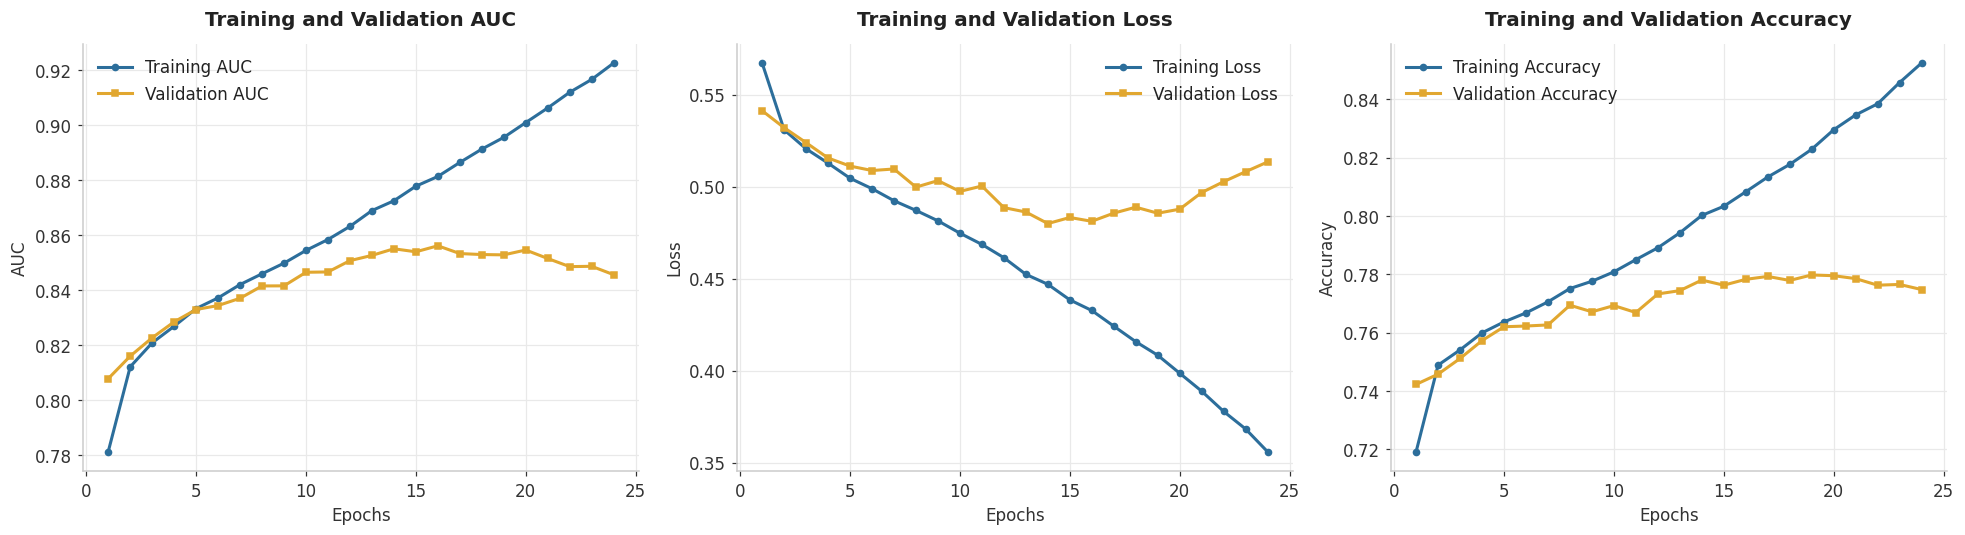

In [47]:
# Model #1 Training results (learning rate 0.001).

graph_train_hist(h1)

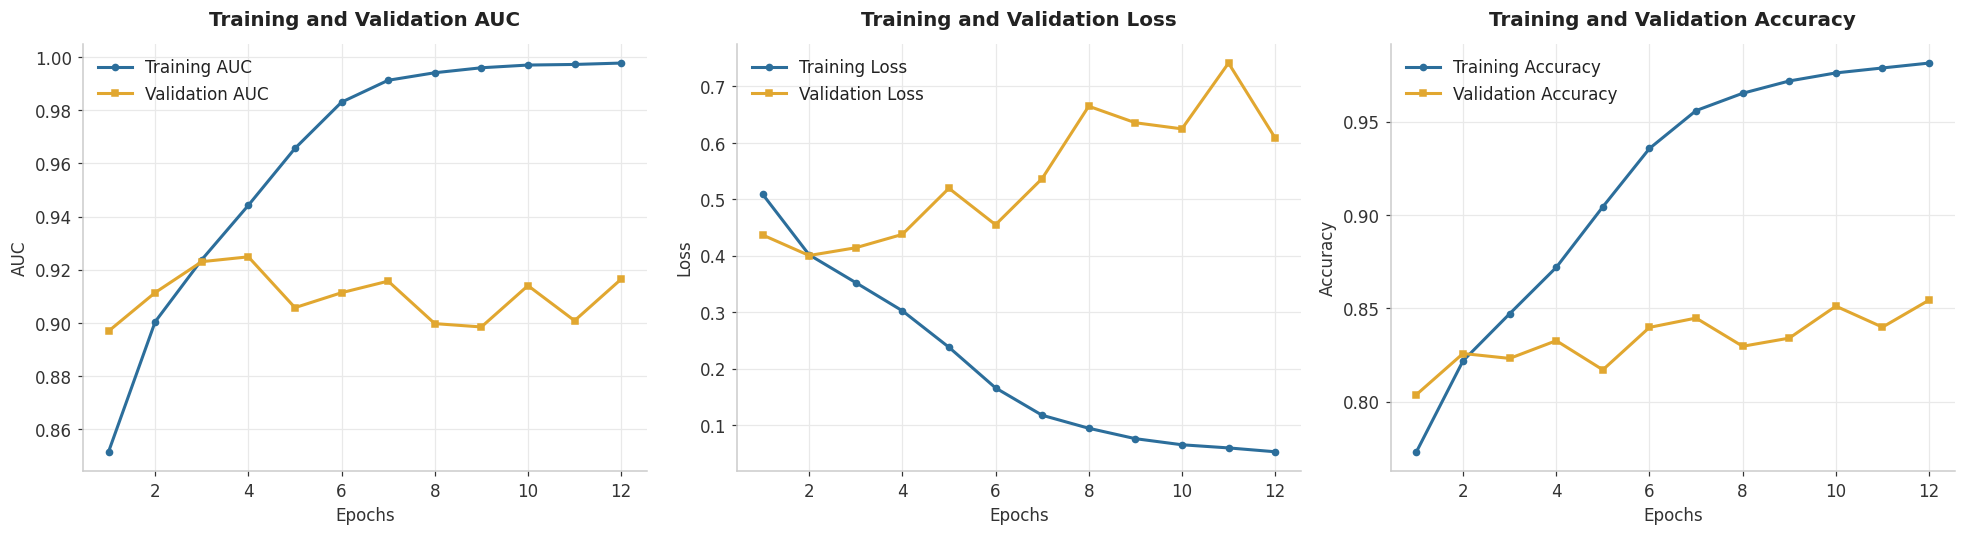

In [48]:
# Model #2 training results (learning rate 0.001).

graph_train_hist(h2)

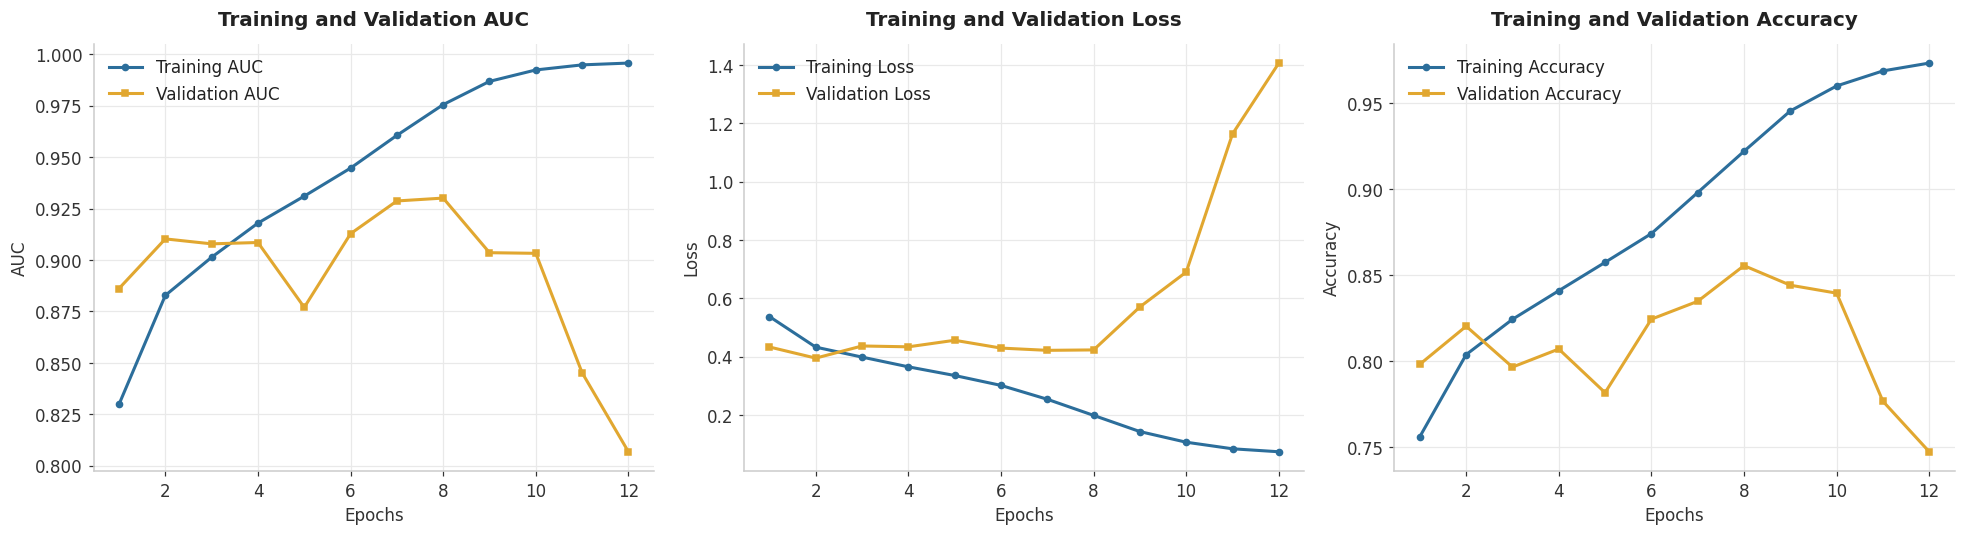

In [49]:
# Model #3 training results (learning rate 0.0001).

graph_train_hist(h3)

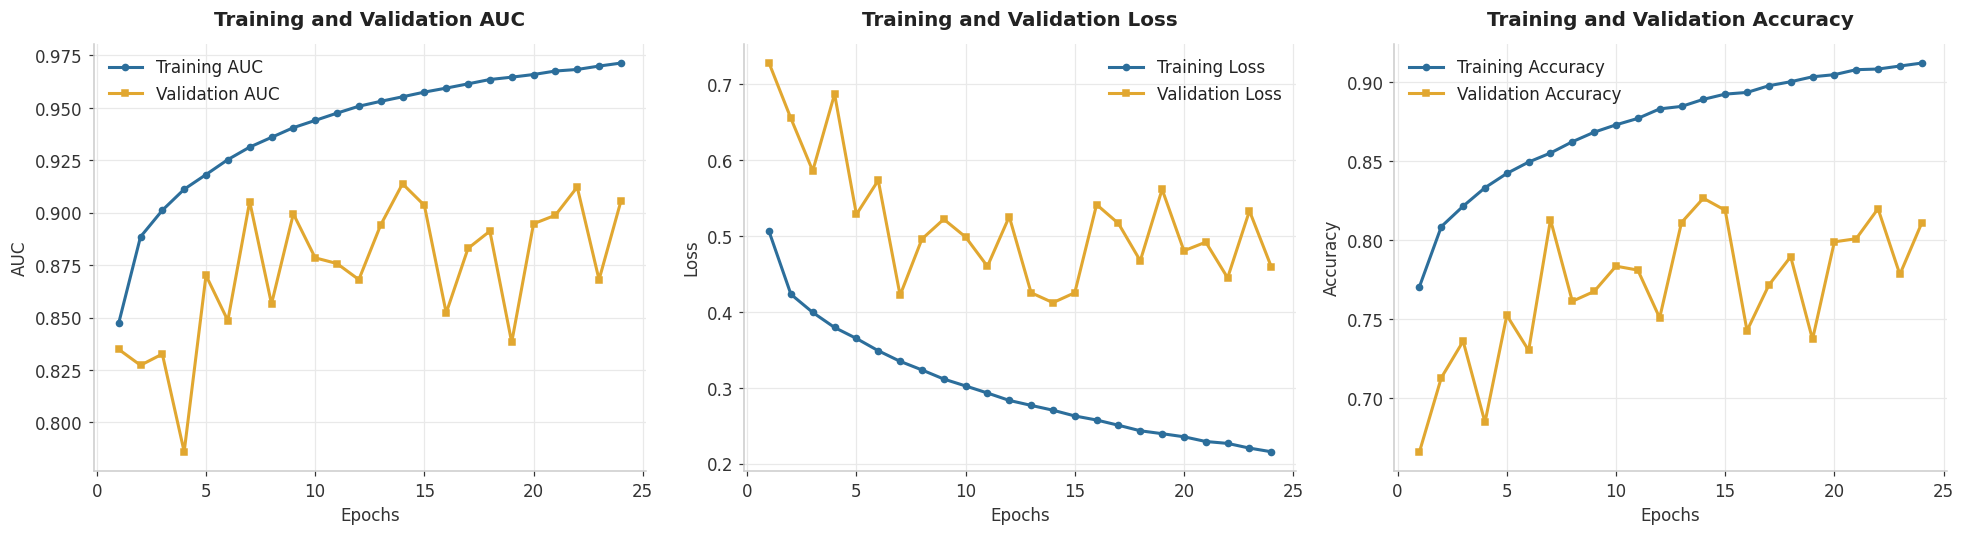

In [50]:
# Model #4 training results (augmented Model #2 base).
graph_train_hist(h4)

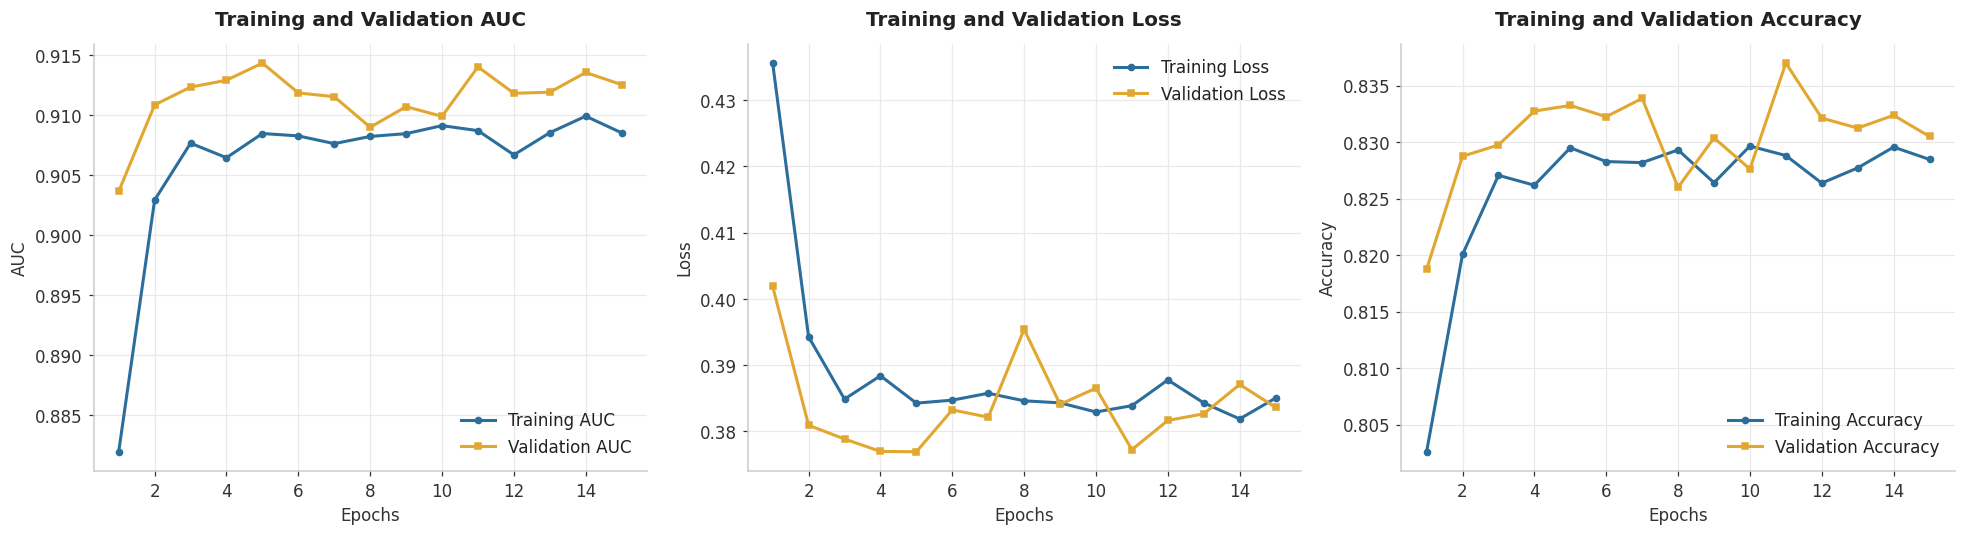

In [51]:
# Model #5 training results (MobileNetV2, stage 1).
graph_train_hist(h5)

<a id="conclusion"></a>
# 5. Conclusion

Across the five models (six variants, counting MobileNetV2 frozen vs. fine-tuned),
the progression tells a clear story — each step isolates the effect of one design
choice:

| Model | What it adds over the previous | Val. AUC | Verdict |
|:------|:-------------------------------|:--------:|:--------|
| Model #1 | 3-block CNN, single dense head — the baseline | 0.856 | Underfits; useful only as a floor |
| Model #2 | 5 conv blocks + batch normalization | 0.925 | Strong from-scratch baseline |
| Model #3 | Deeper dense head (~1M more params) | 0.930\* | Higher peak but val. loss diverges → overfits |
| Model #4 | Model #2 + data augmentation | 0.914 | Best generalization; cleanest, most stable curves |
| Model #5 (frozen) | MobileNetV2 pre-trained feature extractor | 0.914 | Matches custom CNNs with a fraction of the training |
| **Model #5 (fine-tuned)** | Unfreeze + fine-tune the backbone | **0.947** 🏆 | **Best overall** |

\* Model #3's peak is not trustworthy — validation loss diverges, so more capacity
without more regularization simply overfits.

From that progression, several **transferable lessons** stand out — most of them
independent of this particular dataset:

- **Capacity has diminishing returns.** The mid-sized Model #2 beat the heavier
  Model #3: past a point, adding parameters mostly buys overfitting and training
  cost, not accuracy.
- **Batch normalization helped** the deeper networks train stably and was a clear
  step up from the plain baseline.
- **Augmentation improves generalization more than peak score.** Model #4's
  validation loss stopped diverging — the most robust from-scratch model — even
  though its best AUC sat just below Model #2's.
- **Transfer learning is the highest-leverage move.** A pre-trained MobileNetV2,
  then fine-tuned, reached the best AUC (0.947) with far less training than the
  custom CNNs — the usual outcome when labeled data is limited.
- **More data is not a guaranteed win.** Doubling the (balanced) training set did
  not improve results here.

**Where to go next**

- **Streaming input pipelines** (`tf.data`) to train on the full dataset without
  memory limits.
- **Stronger backbones** (EfficientNet, ResNet) and systematic tuning of how many
  layers to unfreeze during fine-tuning.
- **Learning-rate schedules** and other non-default hyperparameters to tame the
  validation-metric swings seen in the from-scratch models.
- **Test-time augmentation** and model ensembling for a further robustness gain.

Even with mostly default hyperparameters and generic architectures, the study
reaches solid performance — and shows that *how* you regularize and initialize a
model (augmentation, pre-training) can matter more than *how big* you make it.

<a id="references"></a>
# 6. References

**Data source**
- [Histopathologic Cancer Detection dataset (Kaggle)](https://www.kaggle.com/competitions/histopathologic-cancer-detection/data) — the data used in this study.
- [PatchCamelyon (PCam) benchmark](https://github.com/basveeling/pcam) — the underlying dataset, derived from the [Camelyon16 challenge](https://camelyon16.grand-challenge.org/).

**Tools & techniques**
- [Reading an image in OpenCV using Python — GeeksforGeeks](https://www.geeksforgeeks.org/reading-image-opencv-using-python/)
- [Python OpenCV `cv2.imread()` method — GeeksforGeeks](https://www.geeksforgeeks.org/python-opencv-cv2-imread-method/)
- [OpenCV `imgcodecs` module documentation](https://docs.opencv.org/3.4/d4/da8/group__imgcodecs.html)
- [Keras `CenterCrop` preprocessing layer](https://keras.io/api/layers/preprocessing_layers/image_preprocessing/center_crop/)
- [Keras `Rescaling` preprocessing layer](https://keras.io/api/layers/preprocessing_layers/image_preprocessing/rescaling/)
- [Keras data loading utilities](https://keras.io/api/data_loading/)
- [pandas API reference](https://pandas.pydata.org/docs/reference/index.html)
- [What is Batch Normalization in Deep Learning? — GeeksforGeeks](https://www.geeksforgeeks.org/what-is-batch-normalization-in-deep-learning/)
- [Keras Applications — MobileNetV2](https://keras.io/api/applications/mobilenet/)
- [TensorFlow: Transfer learning and fine-tuning](https://www.tensorflow.org/tutorials/images/transfer_learning)
- [TensorFlow: Load and preprocess images](https://www.tensorflow.org/tutorials/load_data/images)